# Proyek Analisis Data: Bike Sharing Dataset
Dalam era mobilitas modern, layanan bike sharing menjadi solusi transportasi yang ramah lingkungan dan efisien. Untuk meningkatkan kualitas layanan, penting untuk memahami pola penggunaan sepeda berdasarkan faktor waktu, musim, dan kondisi cuaca.
Analisis ini bertujuan untuk menggali insight dari data penggunaan sepeda guna mendukung pengambilan keputusan berbasis data.
- **Nama:** Sindi Prasetiyani
- **Email:** sindipras5@gmail.com
- **ID Dicoding:** CDCC414D6X1041

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh musim dan kondisi cuaca terhadap jumlah peminjaman sepeda?
- Kapan waktu puncak penggunaan sepeda terjadi, dan bagaimana pola penggunaannya dalam satu hari?

## Import Semua Packages/Library yang Digunakan

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [11]:
day_df = pd.read_csv('Data/day.csv')
hour_df = pd.read_csv('Data/hour.csv')

display(day_df.head())
display(hour_df.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terbagi menjadi granularitas harian dan per jam
- Variabel mencerminkan faktor lingkungan dan perilaku pengguna

### Assessing Data

In [12]:
print("DAY DATA INFO")
display(day_df.info())

print("\nDESCRIBE")
display(day_df.describe())

print("\nMISSING VALUES")
display(day_df.isna().sum())

print("\nDUPLICATE")
print(day_df.duplicated().sum())

DAY DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None


DESCRIBE


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



MISSING VALUES


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0



DUPLICATE
0


In [13]:
print("HOUR DATA INFO")
display(hour_df.info())

print("\nDESCRIBE")
display(hour_df.describe())

print("\nMISSING VALUES")
display(hour_df.isna().sum())

print("\nDUPLICATE")
print(hour_df.duplicated().sum())

HOUR DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None


DESCRIBE


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000



MISSING VALUES


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0



DUPLICATE
0


**Insight:**
- Tidak ditemukan missing value signifikan
- Tidak terdapat duplikasi data
- Dataset siap untuk tahap cleaning

### Cleaning Data

In [14]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

day_df.rename(columns={'cnt': 'total_rentals'}, inplace=True)
hour_df.rename(columns={'cnt': 'total_rentals'}, inplace=True)

**Insight:**
- Format tanggal telah diperbaiki untuk analisis time-series
- Penamaan kolom lebih deskriptif

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
season_avg = day_df.groupby("season")["total_rentals"].mean().reset_index()
weather_avg = day_df.groupby("weathersit")["total_rentals"].mean().reset_index()

season_avg
weather_avg

,weathersit,total_rentals
0,1,4876.786177
1,2,4035.862348
2,3,1803.285714


**Insight:**
- Musim memiliki dampak signifikan terhadap penggunaan sepeda
- Cuaca buruk secara konsisten menurunkan jumlah peminjaman

## Visualization & Explanatory Analysis

### Pertanyaan 1:

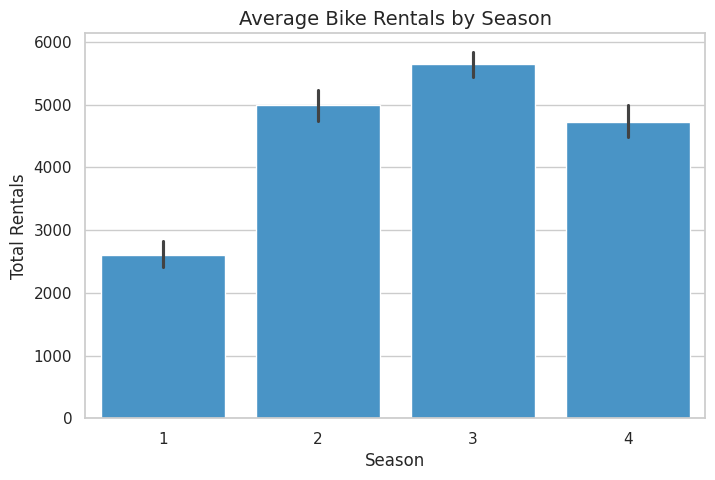

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='season',
    y='total_rentals',
    data=day_df,
    color='#3498DB'
)
plt.title('Average Bike Rentals by Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Total Rentals')
plt.show()

### Pertanyaan 2:

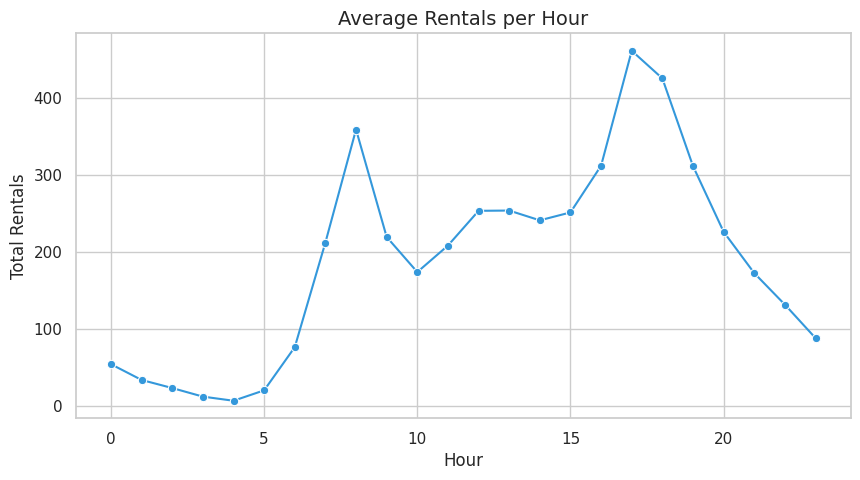

In [21]:
hourly_avg = hour_df.groupby("hr")["total_rentals"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker='o',
    color='#3498DB'
)
plt.title('Average Rentals per Hour', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Total Rentals')
plt.show()

**Insight:**
- Terjadi dua puncak utama → pagi & sore
- Mengindikasikan penggunaan untuk aktivitas kerja (commuting)

## Analisis Lanjutan (Opsional)

**Clustering Sederhana (Binning)**

In [23]:
hour_df['usage_level'] = pd.qcut(hour_df['total_rentals'], q=3, labels=['Low', 'Medium', 'High'])

usage_dist = hour_df['usage_level'].value_counts()
usage_dist

,count
usage_level,
Medium,5823
Low,5797
High,5759


**Visualisasi Clustering**

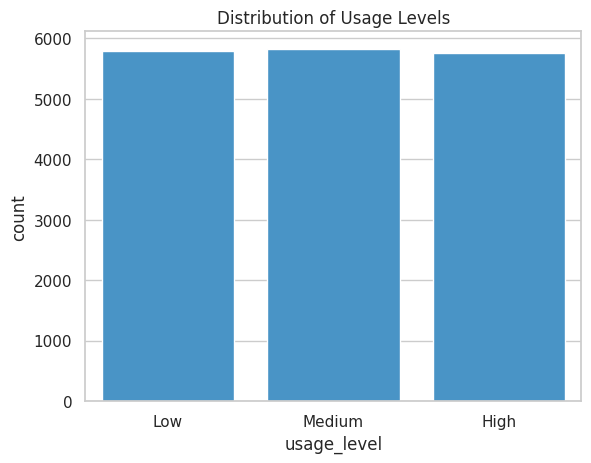

In [24]:
sns.countplot(
    x='usage_level',
    data=hour_df,
    color='#3498DB'
)
plt.title('Distribution of Usage Levels')
plt.show()

**Insight**
- Distribusi penggunaan dapat dikategorikan menjadi 3 level
- Segmentasi ini berguna untuk strategi operasional (penempatan sepeda)

**Correlation Heatmap**

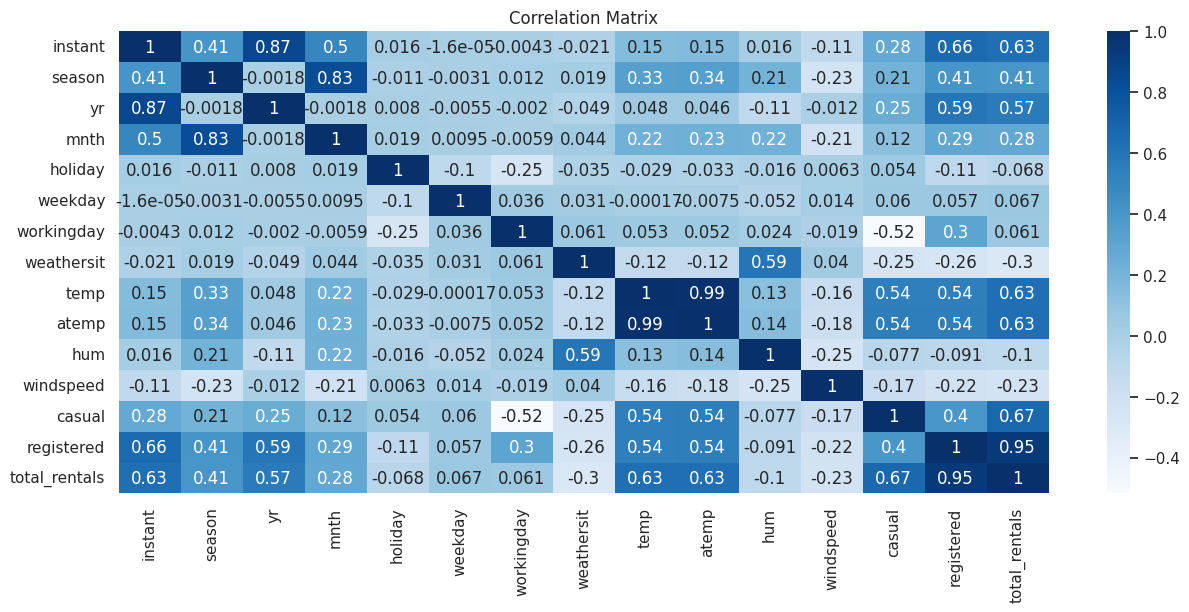

In [26]:
plt.figure(figsize=(15,6))
sns.heatmap(
    day_df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)
plt.title('Correlation Matrix')
plt.show()

- Visualisasi di atas menunjukkan bahwa penggunaan sepeda meningkat pada musim tertentu, yang mengindikasikan adanya pengaruh faktor lingkungan terhadap perilaku pengguna.

## Conclusion

- Faktor lingkungan seperti musim dan cuaca memiliki pengaruh signifikan terhadap jumlah peminjaman sepeda
- Pola penggunaan menunjukkan adanya dua puncak aktivitas harian yang berkaitan dengan jam kerja
- Segmentasi penggunaan menunjukkan distribusi yang dapat dimanfaatkan untuk optimalisasi operasional
- Insight ini dapat digunakan untuk meningkatkan efisiensi distribusi sepeda dan kualitas layanan

In [28]:
os.makedirs("Dashboard", exist_ok=True)

hour_df.to_csv("Dashboard/main_data.csv", index=False)

print("✅ main_data.csv berhasil dibuat!")

✅ main_data.csv berhasil dibuat!
